In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Installing dependencies

In [3]:
!pip install torch accelerate pymatgen pyyaml tqdm kogger matplotlib pandas scipy tensorboard mp_api --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 89.8 MB/s eta 0:00:00
   ━━━━━━

Storing the material project API

In [4]:
%cd "/content/drive/MyDrive/reproducing a paper/MatAltMag"
!sed -i "s/api_key = '.*'/api_key = 'jeSpHnMz90dJ0jad0qfbOFFWocNEt3Fr'/" download.py
!grep "api_key = " download.py   # confirm it now shows your real key, 32 chars, not a placeholder

/content/drive/MyDrive/reproducing a paper/MatAltMag
    api_key = 'jeSpHnMz90dJ0jad0qfbOFFWocNEt3Fr'


Downloading the cif structures

In [5]:
%cd /content/drive/MyDrive/reproducing a paper/MatAltMag

/content/drive/MyDrive/reproducing a paper/MatAltMag


In [6]:
pwd


'/content/drive/MyDrive/reproducing a paper/MatAltMag'

In [7]:
# Replacing kogger by print in download.py
with open('download.py') as f:
    src = f.read()

src = src.replace('import kogger\n', '')
src = src.replace('kogger.info(', 'print(')

with open('download.py', 'w') as f:
    f.write(src)

print(src)  # sanity check the two changed lines are gone/fixed

"""
Download materials from materialsproject.org

"""
from mp_api.client import MPRester
import os.path as osp
import pandas as pd
from tqdm import tqdm


def read_material_ids(data_path):
    """
    Parameters
    ----------
    data_path: file path of sample.csv

    Returns
    -------
    material_ids: list

    """
    df = pd.read_csv(data_path, header=None)
    print('Read {} samples from {}'.format(len(df), data_path))
    material_ids = df[1].tolist()
    return material_ids


def download_materials(material_ids, save_dir, label=1):
    print('Download...')
    chunk_size = 500
    with MPRester(api_key) as mpr:
        ids = []
        for start in tqdm(range(0, len(material_ids), chunk_size)):
            chunk = material_ids[start:start+chunk_size]
            docs = mpr.materials.bonds.search(material_ids=chunk, fields=['material_id', 'structure_graph'])
            for doc in docs:
                struc = doc.structure_graph.structure
                id = doc.material_id

In [8]:
# # Only Run this cell when the structures are not downloaded
# # Dividing the download process into chunks
# with open('download.py') as f:
#     src = f.read()

# old_block = '''    with MPRester(api_key) as mpr:
#         ids = []
#         docs = mpr.bonds.search(material_ids=material_ids, fields=['material_id', 'structure_graph'])
#         length = len(docs)
#         for idx in tqdm(range(length)):
#             struc = docs[idx].structure_graph.structure
#             id = docs[idx].material_id
#             ids.append(id)
#             # save file,  'data/mp-22862.cif'
#             struc.to(filename=osp.join(save_dir, '{}.cif'.format(id)))'''

# new_block = '''    chunk_size = 500
#     with MPRester(api_key) as mpr:
#         ids = []
#         for start in tqdm(range(0, len(material_ids), chunk_size)):
#             chunk = material_ids[start:start+chunk_size]
#             docs = mpr.materials.bonds.search(material_ids=chunk, fields=['material_id', 'structure_graph'])
#             for doc in docs:
#                 struc = doc.structure_graph.structure
#                 id = doc.material_id
#                 ids.append(id)
#                 # save file,  'data/mp-22862.cif'
#                 struc.to(filename=osp.join(save_dir, '{}.cif'.format(id)))'''

# assert old_block in src, "original block not found — paste didn't match, tell me and I'll adjust"
# src = src.replace(old_block, new_block)

# with open('download.py', 'w') as f:
#     f.write(src)

# print("Patched successfully")

# # Downloading the cif structures
# for label, path in [(1, 'data/label1.csv'), (0, 'data/label0.csv'), (-1, 'data/candidate.csv')]:
#     with open('download.py') as f:
#         lines = f.readlines()

#     new_lines = []
#     for line in lines:
#         if line.strip().startswith('label ='):
#             new_lines.append(f'    label = {label}\n')
#         elif line.strip().startswith("data_path = 'data/") and not line.strip().startswith('#'):
#             new_lines.append(f"    data_path = '{path}'\n")
#         else:
#             new_lines.append(line)

#     with open('download_run.py', 'w') as f:
#         f.writelines(new_lines)

#     print(f"\n=== Target: label={label}, path={path} ===")
#     !grep -E "^\s*(label|data_path) =" download_run.py
#     !python download_run.py

Configure accelerate for Colab's single GPU

In [9]:
!accelerate config default --config_file yamls/accelerate.yaml

Configuration already exists at yamls/accelerate.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.


### We will skip the pretraining and fine tunning step for now as it would takes a very long time, instead we used the pretrained weights of the paper to reproduce the results.

Running pre-training

In [10]:
# !python pretrain.py --file yamls/pretrain.yaml

Storing checkpoints for fine tuning step

In [11]:
# Replace '0' with experiment name and '10epoch' with number of epochs used in 'pretrain.yaml' file
# !cp -r checkpoints/pre_checkpoint-0-10epoch checkpoints/pre_checkpoint-0

Fine tunning the classifier

In [12]:
# !python train.py --file yamls/train.yaml

### Prediction on candidates data

In [13]:
# Checking the checkpoint-27
!ls -la checkpoints/checkpoint-27

total 82041
-rw------- 1 root root 55961221 Jul 20 08:01 optimizer.bin
-rw------- 1 root root 28030689 Jul 20 08:01 pytorch_model.bin
-rw------- 1 root root    15627 Jul 20 08:01 random_states_0.pkl
-rw------- 1 root root      627 Jul 20 08:01 scheduler.bin


In [14]:
# Checking 'predict.yaml' matches the architecture of checkpoint
!grep -E "experiment_name|ckpt_path" yamls/predict.yaml

experiment_name: '27'
ckpt_path: 'checkpoints/checkpoint-{}'


In [16]:
# Confirming the the candidate dataset is ready
!wc -l data/id_prop_-1.csv
!ls data/*.cif | wc -l

41918 data/id_prop_-1.csv
66993


In [17]:
# Predict all together at once
# !python predict.py --file yamls/predict.yaml


In [18]:
# Predict in chunks
!python predict_resumable.py --file yamls/predict.yaml --chunk_size 1000

41918 candidates -> 42 chunks of size 1000
[chunk 0/41] already predicted, skipping
[chunk 1/41] already predicted, skipping
[chunk 2/41] already predicted, skipping
[chunk 3/41] already predicted, skipping
[chunk 4/41] already predicted, skipping
[chunk 5/41] already predicted, skipping
[chunk 6/41] already predicted, skipping
[chunk 7/41] already predicted, skipping
[chunk 8/41] already predicted, skipping
[chunk 9/41] already predicted, skipping
[chunk 10/41] already predicted, skipping
[chunk 11/41] already predicted, skipping
[chunk 12/41] already predicted, skipping
[chunk 13/41] already predicted, skipping
[chunk 14/41] already predicted, skipping
[chunk 15/41] already predicted, skipping
[chunk 16/41] already predicted, skipping
[chunk 17/41] already predicted, skipping
[chunk 18/41] already predicted, skipping
[chunk 19/41] already predicted, skipping
[chunk 20/41] already predicted, skipping
[chunk 21/41] already predicted, skipping
[chunk 22/41] already predicted, skipping
[

Filtering materials with probability > 0.9

In [ ]:
# import pandas as pd
# df = pd.read_csv('out/predict-27.csv', header=None, names=['id', 'prob'])
# candidates = df[df['prob'] > 0.9]
# print(len(candidates))
# candidates.head(60)

### **Comparing The Results**

#### Line Plot

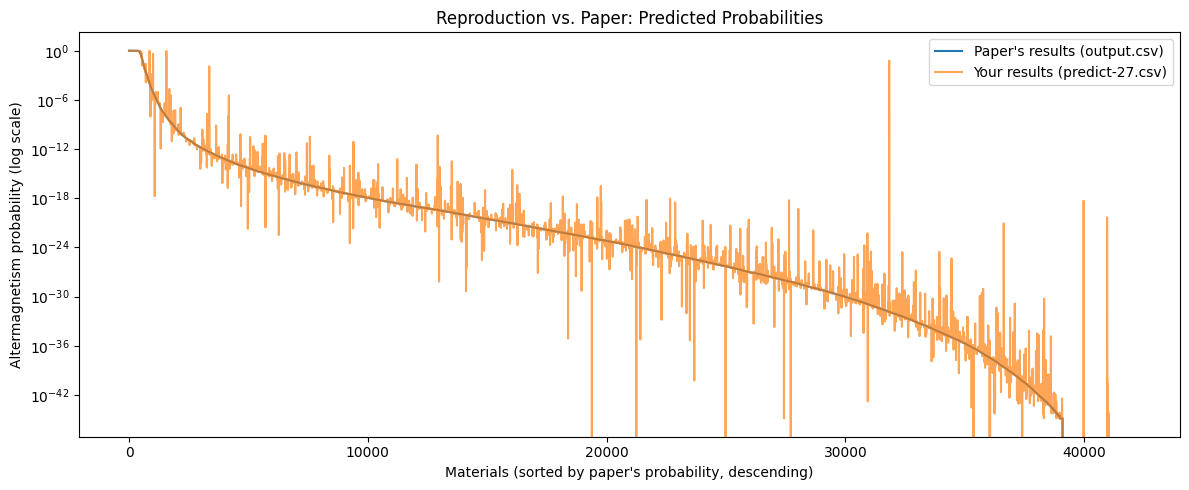

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# load both files
o = pd.read_csv('/content/drive/MyDrive/reproducing a paper/MatAltMag/out/output.csv', header=None, names=['id', 'prob'])
p = pd.read_csv('/content/drive/MyDrive/reproducing a paper/MatAltMag/out/predict-27.csv', header=None, names=['id', 'prob'])

# only compare materials present in both files, aligned by id
merged = p.merge(o, on='id', suffixes=('_mine', '_theirs'))

# sort by the paper's probability so both lines follow the same x-order
merged = merged.sort_values('prob_theirs', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(merged['prob_theirs'], label="Paper's results (output.csv)", linewidth=1.5)
plt.plot(merged['prob_mine'], label='Your results (predict-27.csv)', linewidth=1.5, alpha=0.7)

plt.yscale('log')
plt.xlabel('Materials (sorted by paper\'s probability, descending)')
plt.ylabel('Altermagnetism probability (log scale)')
plt.title('Reproduction vs. Paper: Predicted Probabilities')
plt.legend()
plt.tight_layout()
# plt.savefig('comparison_plot.png', dpi=150)
plt.show()

#### Scatter Plot

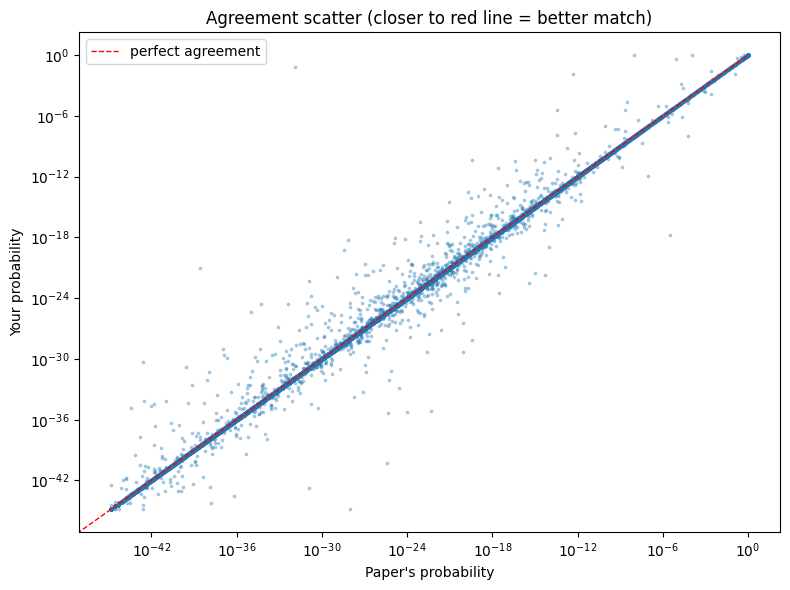

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

o = pd.read_csv('/content/drive/MyDrive/reproducing a paper/MatAltMag/out/output.csv', header=None, names=['id', 'prob'])
p = pd.read_csv('/content/drive/MyDrive/reproducing a paper/MatAltMag/out/predict-27.csv', header=None, names=['id', 'prob'])

merged = p.merge(o, on='id', suffixes=('_mine', '_theirs'))

plt.figure(figsize=(8, 6))
plt.scatter(merged['prob_theirs'], merged['prob_mine'], s=3, alpha=0.3)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='perfect agreement')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Paper's probability")
plt.ylabel('Your probability')
plt.title('Agreement scatter (closer to red line = better match)')
plt.legend()
plt.tight_layout()
# plt.savefig('comparison_scatter.png', dpi=150)
plt.show()